# Polygons Size Distribution

In [4]:
import geopandas as gpd
import plotly.express as px
import pandas as pd
import numpy as np
import os
import math

# ── Load shapefile (WGS 84) and reproject to UTM 20S (SIRGAS 2000) ──
SCRIPT_DIR = os.path.dirname(os.path.abspath("__file__"))
SHP_DIR = os.path.join(SCRIPT_DIR, "data", "data_shp")
if os.path.exists(os.path.expanduser("~/thesis_scripts/data_shp")):
    SHP_DIR = os.path.expanduser("~/thesis_scripts/data_shp")

gdf = gpd.read_file(os.path.join(SHP_DIR, "label_polygons.shp"))
print(f"Original CRS: {gdf.crs}")

# Reproject WGS 84 -> SIRGAS 2000 / UTM zone 20S for accurate area
gdf_utm = gdf.to_crs("EPSG:31980")
gdf_utm["area_m2"] = gdf_utm.geometry.area
gdf_utm["area_px"] = (gdf_utm["area_m2"] / 10).round().astype(int)  # 10 m²/pixel

print(f"Reprojected CRS: {gdf_utm.crs}")
print(f"Polygons: {len(gdf_utm)}")
print(f"Area range: {gdf_utm['area_m2'].min():.0f} – {gdf_utm['area_m2'].max():.0f} m²  |  {gdf_utm['area_px'].min()} – {gdf_utm['area_px'].max()} px")
print(f"Median: {gdf_utm['area_m2'].median():.0f} m² ({gdf_utm['area_px'].median():.0f} px)  |  Mean: {gdf_utm['area_m2'].mean():.0f} m² ({gdf_utm['area_px'].mean():.0f} px)")

# ── Percentile table (m² and pixels) ──
percentiles = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
pct_m2 = [gdf_utm["area_m2"].quantile(p) for p in percentiles]
pct_px = [int(round(m2 / 10)) for m2 in pct_m2]

pct_df = pd.DataFrame({
    "Percentile": [f"P{int(p*100)}" for p in percentiles],
    "Area (m²)": [int(round(v)) for v in pct_m2],
    "Area (pixels)": pct_px,
})
print("\nPercentiles:")
print(pct_df.to_string(index=False))

# ── Foundation model image coverage ──
FM_INPUT_SIZES = {
    "CROMA": 120,      # 120x120 px (534 cropped to nearest multiple of 8)
    "TerraFM": 224,    # 224x224 px
    "Clay v1.5": 256,  # 256x256 px
    "SkySense": 64,    # 64x64 px
}
# Image area in pixels (input sizes are already in pixels)
fm_image_area_px = {name: size * size for name, size in FM_INPUT_SIZES.items()}

print("\nFM image area (pixels):")
for name, area in fm_image_area_px.items():
    print(f"  {name}: {FM_INPUT_SIZES[name]}x{FM_INPUT_SIZES[name]} = {area:,} px")

# ── Table: images needed per FM per percentile ──
rows = []
for i, p in enumerate(percentiles):
    row = {"Percentile": f"P{int(p*100)}", "Area (m²)": pct_df["Area (m²)"].iloc[i], "Area (px)": pct_px[i]}
    for name, img_area in fm_image_area_px.items():
        row[name] = max(1, math.ceil(pct_px[i] / img_area))
    rows.append(row)

coverage_df = pd.DataFrame(rows)
print("\nImages needed to cover polygon area per FM:")
print(coverage_df.to_string(index=False))

# ── Histogram: full distribution (pixels) ──
fig1 = px.histogram(
    gdf_utm, x="area_px", nbins=50, color_discrete_sequence=["forestgreen"],
    labels={"area_px": "Area (pixels, 10 m²/px)"},
    title="Polygon Size Distribution – all (1 pixel = 10 m²)",
)
med_px = int(gdf_utm["area_px"].median())
mean_px = int(gdf_utm["area_px"].mean())
fig1.add_vline(x=med_px, line_dash="dash", line_color="red",
               annotation_text=f"Median: {med_px} px")
fig1.add_vline(x=mean_px, line_dash="dash", line_color="orange",
               annotation_text=f"Mean: {mean_px} px")
fig1.update_layout(yaxis_title="Number of polygons")
fig1.show()

# ── Histogram: zoomed to 95th percentile (pixels) ──
p95_px = int(gdf_utm["area_px"].quantile(0.95))
subset = gdf_utm[gdf_utm["area_px"] <= p95_px]
fig2 = px.histogram(
    subset, x="area_px", nbins=40, color_discrete_sequence=["forestgreen"],
    labels={"area_px": "Area (pixels, 10 m²/px)"},
    title=f"Polygon Size Distribution – ≤ P95 = {p95_px} px ({p95_px * 10} m²)",
)
fig2.add_vline(x=med_px, line_dash="dash", line_color="red",
               annotation_text=f"Median: {med_px} px")
fig2.update_layout(yaxis_title="Number of polygons")
fig2.show()

# ── Summary by CLASSNAME (m² and pixels) ──
print("\nArea statistics by class:")
stats = gdf_utm.groupby("CLASSNAME").agg(
    count=("area_px", "size"),
    mean_m2=("area_m2", "mean"), median_m2=("area_m2", "median"), min_m2=("area_m2", "min"), max_m2=("area_m2", "max"),
    mean_px=("area_px", "mean"), median_px=("area_px", "median"), min_px=("area_px", "min"), max_px=("area_px", "max"),
).round(0).astype(int)
print(stats.to_string())

Original CRS: EPSG:4326
Reprojected CRS: EPSG:31980
Polygons: 389
Area range: 39685 – 18646769 m²  |  3969 – 1864677 px
Median: 153856 m² (15386 px)  |  Mean: 430437 m² (43044 px)

Percentiles:
Percentile  Area (m²)  Area (pixels)
        P5      68416           6842
       P10      77736           7774
       P25      99816           9982
       P50     153856          15386
       P75     293201          29320
       P90     614476          61448
       P95    1256804         125680
       P99    5379442         537944

FM image area (pixels):
  CROMA: 120x120 = 14,400 px
  TerraFM: 224x224 = 50,176 px
  Clay v1.5: 256x256 = 65,536 px
  SkySense: 64x64 = 4,096 px

Images needed to cover polygon area per FM:
Percentile  Area (m²)  Area (px)  CROMA  TerraFM  Clay v1.5  SkySense
        P5      68416       6842      1        1          1         2
       P10      77736       7774      1        1          1         2
       P25      99816       9982      1        1          1         3
 


Area statistics by class:
                              count  mean_m2  median_m2  min_m2    max_m2  mean_px  median_px  min_px   max_px
CLASSNAME                                                                                                     
Clear-cut bare soil             271   218299     148239   62760   1578453    21830      14824    6276   157845
Clear-cut vegetation             10   215151     148143   81697    599631    21515      14814    8170    59963
Degradation                      40   461586     223906   63134   2724546    46159      22390    6313   272455
Disorderly Selective logging     20  3006175    1577125  226223  18646769   300617     157712   22622  1864677
Fire scar                        44   209057     131639   39685   1457241    20906      13164    3969   145724
Geometric Selective logging       4  4586038    2271812  126762  13673767   458604     227181   12676  1367377


In [5]:
coverage_df

,Percentile,Area (m²),Area (px),CROMA,TerraFM,Clay v1.5,SkySense
0,P5,68416,6842,1,1,1,2
1,P10,77736,7774,1,1,1,2
2,P25,99816,9982,1,1,1,3
3,P50,153856,15386,2,1,1,4
4,P75,293201,29320,3,1,1,8
5,P90,614476,61448,5,2,1,16
6,P95,1256804,125680,9,3,2,31
7,P99,5379442,537944,38,11,9,132


# Polygons Date Distribution

In [6]:
import pandas as pd

# ── Parse VIEW_DATE ──
gdf_utm["VIEW_DATE"] = pd.to_datetime(gdf_utm["VIEW_DATE"])
gdf_utm["year_month"] = gdf_utm["VIEW_DATE"].dt.to_period("M")

# ── Monthly polygon count (timeline) ──
monthly = gdf_utm.groupby("year_month").size().reset_index(name="count")
monthly["date"] = monthly["year_month"].dt.to_timestamp()

fig3 = px.bar(
    monthly, x="date", y="count", color_discrete_sequence=["steelblue"],
    labels={"date": "Date", "count": "Number of polygons"},
    title="Polygons per Month",
)
fig3.show()

# ── Seasonality (month of year) per class ──
month_labels = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
                7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}
gdf_utm["month_name"] = gdf_utm["month"].astype(int).map(month_labels)

season_df = gdf_utm.groupby(["month", "month_name", "CLASSNAME"]).size().reset_index(name="count")
season_df = season_df.sort_values("month")

fig4 = px.bar(
    season_df, x="month_name", y="count", color="CLASSNAME", barmode="group",
    labels={"month_name": "Month", "count": "Number of polygons", "CLASSNAME": "Class"},
    title="Seasonality (month of year) per Class",
    category_orders={"month_name": list(month_labels.values())},
)
fig4.show()

# ── Summary ──
print("Date range:", gdf_utm["VIEW_DATE"].min().date(), "to", gdf_utm["VIEW_DATE"].max().date())
print(f"\nPolygons per class:")
print(gdf_utm["CLASSNAME"].value_counts().to_string())

Date range: 2023-02-14 to 2023-12-13

Polygons per class:
CLASSNAME
Clear-cut bare soil             271
Fire scar                        44
Degradation                      40
Disorderly Selective logging     20
Clear-cut vegetation             10
Geometric Selective logging       4


In [7]:
!pip install scienceplots

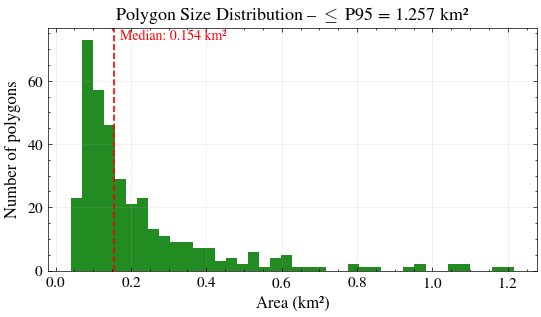

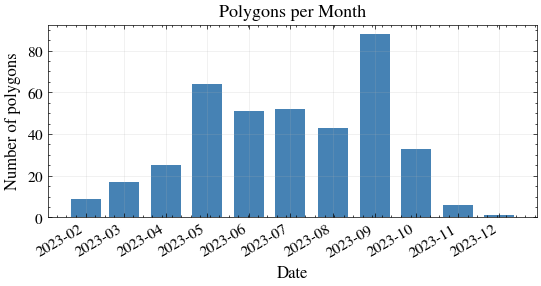

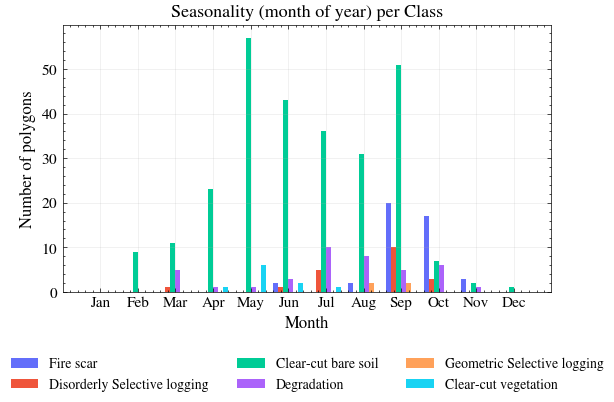

In [9]:
# ── Publication figures: same charts, matplotlib + science style, PDF ──
import matplotlib.pyplot as plt
import numpy as np
import scienceplots  # noqa: F401

plt.style.use(['science', 'no-latex'])   # drop 'no-latex' if LaTeX is installed

TEXT_W = 160 / 25.4   # 6.30 in = your text width
FIGDIR = "/Users/angelicamariamorenorojas/Desktop/Master/thesis/manuscript/manuscript_tropical_forest_disturbance/figures"

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 12, 'axes.titlesize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 10,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.5,
    'savefig.bbox': 'tight',
})

med_px  = int(gdf_utm["area_px"].median())
mean_px = int(gdf_utm["area_px"].mean())
p95_px  = int(gdf_utm["area_px"].quantile(0.95))


# ── Polygon size distribution, zoomed to P95, in km² ──
gdf_utm["area_km2"] = gdf_utm["area_m2"] / 1e6

med_km2 = gdf_utm["area_km2"].median()
p95_km2 = gdf_utm["area_km2"].quantile(0.95)
subset  = gdf_utm[gdf_utm["area_km2"] <= p95_km2]

fig, ax = plt.subplots(figsize=(TEXT_W, TEXT_W * 0.5))
ax.hist(subset["area_km2"], bins=40, color="forestgreen")
ax.axvline(med_km2, color="red", ls="--", lw=1.2)
ax.annotate(f"Median: {med_km2:.3f} km²", xy=(med_km2, 0.95), xycoords=('data', 'axes fraction'),
            xytext=(5, 0), textcoords='offset points', color="red", fontsize=10)
ax.set_xlabel("Area (km²)")
ax.set_ylabel("Number of polygons")
ax.set_title(f"Polygon Size Distribution – $\\leq$ P95 = {p95_km2:.3f} km²")
fig.savefig(f"{FIGDIR}/polygon_size_p95.pdf")

# ── Fig 3: polygons per month ──
fig, ax = plt.subplots(figsize=(TEXT_W, TEXT_W * 0.45))
ax.bar(monthly["date"], monthly["count"], width=22, color="steelblue")
ax.set_xlabel("Date")
ax.set_ylabel("Number of polygons")
ax.set_title("Polygons per Month")
fig.autofmt_xdate()
fig.savefig(f"{FIGDIR}/polygons_per_month.pdf")

# ── Fig 4: seasonality per class, legend below the axes ──
PLOTLY = ["#636EFA", "#EF553B", "#00CC96", "#AB63FA", "#FFA15A", "#19D3F3"]
months  = list(month_labels.values())
classes = list(gdf_utm["CLASSNAME"].unique())
x = np.arange(12)
w = 0.8 / len(classes)

fig, ax = plt.subplots(figsize=(TEXT_W, TEXT_W * 0.55))
for i, cls in enumerate(classes):
    counts = (gdf_utm[gdf_utm["CLASSNAME"] == cls]
            .groupby("month").size().reindex(range(1, 13), fill_value=0).values)
    ax.bar(x + i * w - 0.4 + w / 2, counts, width=w, color=PLOTLY[i % len(PLOTLY)], label=cls)

ax.set_xticks(x); ax.set_xticklabels(months)
ax.set_xlabel("Month"); ax.set_ylabel("Number of polygons")
ax.set_title("Seasonality (month of year) per Class")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=3, frameon=False)
fig.savefig(f"{FIGDIR}/seasonality_per_class.pdf")